In [108]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri
import pandas as pd
import rasterio
from collections import Counter,defaultdict
from matplotlib.path import Path
import matplotlib.patches as mpatches
import MFO
plt.rcParams['font.sans-serif']=['SimHei'] #display Chinese labels
plt.rcParams['axes.unicode_minus']=False #display the minus sign
print("Environment creation successful!")

Environment creation successful!


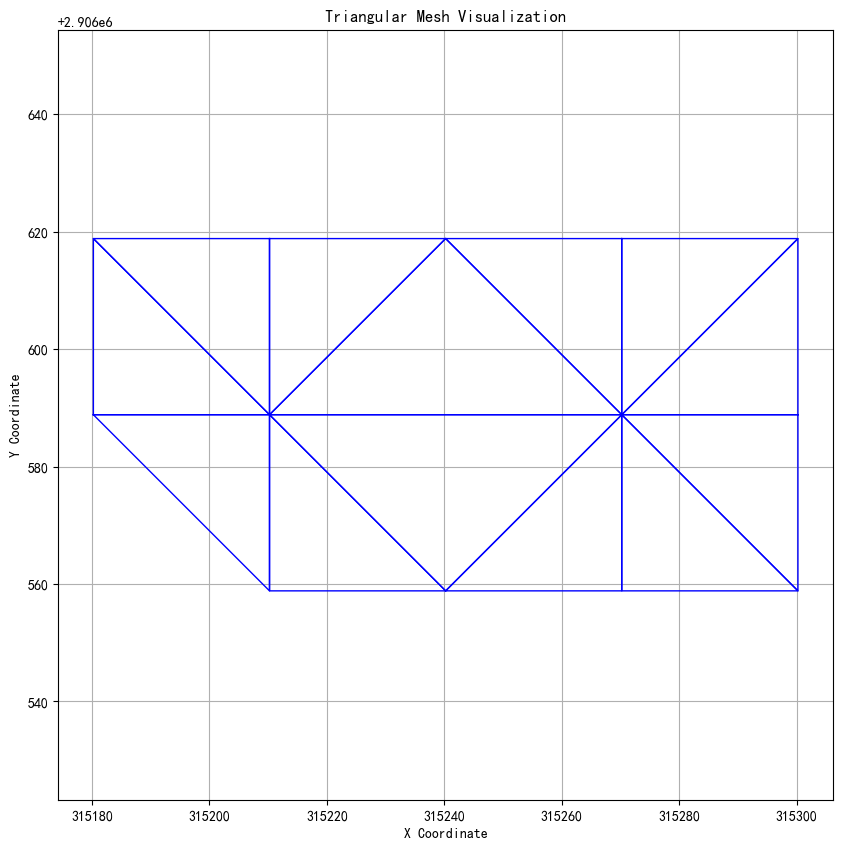

In [109]:
# Read data
file_path = "./Test_triangular_network.csv"
df = pd.read_csv(file_path)

# Group by Tri_Index
triangles = df.groupby("Tri_Index")

# Drawing
plt.figure(figsize=(10, 10))
for _, group in triangles:

    x = group["x"].tolist()
    y = group["y"].tolist()

    x.append(x[0])
    y.append(y[0])

    plt.plot(x, y, 'b-', linewidth=1)

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Triangular Mesh Visualization")
plt.axis("equal")
plt.grid(True)

plt.show()


In [110]:
class TriangularMesh:
    """Used for storing triangular network data and providing query functions"""
    def __init__(self, file_path):
        self.triangles = {}  # Store triangle information
        self.vertex_index = {}  # Store vertex numbers
        self.adjacency = defaultdict(set)  # Store the adjacent points of each vertex
        self.boundary_points = set()  # Storage boundary point

        df = pd.read_csv(file_path)
        
        # Add vertex numbers to each triangle and record the adjacent points
        for tri_index, group in df.groupby("Tri_Index"):
            if len(group) == 3:
                vertices = list(zip(group["x"], group["y"]))
                ls_value = group["LS"].iloc[0]  # LS 值
                self.triangles[tri_index] = (vertices, ls_value)
                
                # Add a numbered index for each vertex
                for i, vertex in enumerate(vertices):
                    if vertex not in self.vertex_index:
                        self.vertex_index[vertex] = len(self.vertex_index)
                    
                    # Update the adjacent points of the vertex (that is, the other two vertices of the triangle)
                    for j in range(3):
                        if vertices[j] != vertex:
                            self.adjacency[vertex].add(vertices[j])
                            
        # Calculate and store the boundary points
        self._compute_boundary_points()

    def _compute_boundary_points(self):
        """Calculate and store the boundary points in the triangular network in advance"""
        edges_count = Counter()

        for vertices, _ in self.triangles.values():
            # Count the three sides of each triangle
            for i in range(3):
                edge = tuple(sorted([vertices[i], vertices[(i + 1) % 3]]))
                edges_count[edge] += 1

        # Boundary edges: Edges with an occurrence count of 1
        for edge, count in edges_count.items():
            if count == 1:
                self.boundary_points.update(edge)

    def get_triangle(self, tri_index):
        """Query the triangle vertices and LS based on Tri_Index"""
        return self.triangles.get(tri_index, None)
    
    def get_adjacent_vertices(self, vertex):
        """Obtain the adjacent points connected to the specified vertex"""
        return self.adjacency.get(vertex, set())
    
    def get_boundary_points(self):
        """Return the pre-calculated boundary points"""
        return self.boundary_points
    
    def get_triangles_by_vertex(self, vertex):
        """Query the Tri_Index of all triangles that are topologically associated with the specified vertex."""
        associated_triangles = []
        for tri_index, (vertices, _) in self.triangles.items():
            if vertex in vertices:
                associated_triangles.append(tri_index)
        return associated_triangles

def compute_subcentroids(triangle):
    """Calculate the centroids of the three smaller triangles within a single triangle."""
    if triangle is None:
        raise ValueError("Error:This Tri_Index does not exist!")

    vertices, _ = triangle

    centroid_main = tuple(sum(coord) / 3 for coord in zip(*vertices))

    subcentroids = [
        tuple(sum(coord) / 3 for coord in zip(vertices[0], vertices[1], centroid_main)),
        tuple(sum(coord) / 3 for coord in zip(vertices[1], vertices[2], centroid_main)),
        tuple(sum(coord) / 3 for coord in zip(vertices[2], vertices[0], centroid_main))
    ]
    
    return subcentroids

# **Sorting angle method: Ensure that adjacent points can correctly form a polygon**
def sort_adjacent_vertices(vertex, neighbors):
    """
    Sort the adjacent points by angle to ensure that they form a polygon in sequence.
    :param vertex: (x, y) A reference point for sorting adjacent points is required.
    :param neighbors: [(x1, y1), (x2, y2), ...] All the adjacent points of this point
    :return: The sorted list of adjacent points
    """
    if len(neighbors) < 3:
        return None
    
    x0, y0 = vertex
    angles = [(np.arctan2(y - y0, x - x0), (x, y)) for x, y in neighbors]
    sorted_neighbors = [point for _, point in sorted(angles)]
    
    return sorted_neighbors


# **Determining whether a polygon is convex using the cross-product method**
def is_convex_polygon(vertex, sorted_neighbors):
    """
    Determine whether the polygon formed by adjacent points is a convex polygon using the cross-product method
    :param vertex: (x, y): The reference points that need to be checked
    :param sorted_neighbors: The sorted list of adjacent points
    :return: True (convex polygon) or False (concave polygon)
    """
    if sorted_neighbors is None:
        return False
    
    n = len(sorted_neighbors)
    sign = None

    for i in range(n):
        x1, y1 = sorted_neighbors[i]
        x2, y2 = sorted_neighbors[(i + 1) % n]

        dx1, dy1 = x1 - vertex[0], y1 - vertex[1]
        dx2, dy2 = x2 - vertex[0], y2 - vertex[1]

        cross_product = dx1 * dy2 - dy1 * dx2

        if sign is None:
            sign = np.sign(cross_product)
        elif sign != np.sign(cross_product):
            return False
    
    return True

def select_movable_vertex(tri_index, mesh):
    """Select a movable point within the specified triangle."""
    vertices, _ = mesh.get_triangle(tri_index)
    if not vertices:
        raise ValueError(f"Triangle {tri_index} does not exist!")

    boundary_points = mesh.get_boundary_points()
    min_neighbors = float('inf')
    selected_vertex = None

    for vertex in vertices:
        if vertex in boundary_points:
            continue

        neighbors = mesh.get_adjacent_vertices(vertex)
        if len(neighbors) < 3:
            continue

        # check whether the polygon formed by the adjacent points is a convex polygon.
        sorted_neighbors = sort_adjacent_vertices(vertex, neighbors)
        if is_convex_polygon(vertex, sorted_neighbors):
            # Select the vertex with the fewest adjacent points
            if len(neighbors) < min_neighbors:
                min_neighbors = len(neighbors)
                selected_vertex = vertex

    return selected_vertex  # Return the vertices that meet the conditions. If none exist, return None.

def get_raster_value_at_points(raster, transform, points):
    """Obtain the raster values of multiple points"""
    raster_values = []
    width, height = raster.shape
    nodata_value = None
    
    for x, y in points:
        col, row = ~transform * (x, y)
        row, col = int(row), int(col)
        
        if 0 <= row < height and 0 <= col < width:
            value = raster[row, col]
            if value == nodata_value:
                value = None
            raster_values.append(value)
        else:
            raster_values.append(None)
    
    return raster_values


def get_class_from_A(A):
    """Return the class value based on the A value."""
    if A < 500:
        return 1
    elif 500 <= A < 2500:
        return 2
    elif 2500 <= A < 5000:
        return 3
    elif 5000 <= A < 8000:
        return 4
    elif 8000 <= A < 15000:
        return 5
    else:
        return 6

def get_lbub(points):
    """
    Find the minimum and maximum coordinates of the given point list.
    :param:
        points (list of tuples):The list of coordinates of the points, each point is a tuple consisting of two elements (x, y).
    :return:
        tuple:It contains two tuples. The first tuple is [x_min, y_min], and the second tuple is [x_max, y_max].
    """

    x_coords = [point[0] for point in points]
    y_coords = [point[1] for point in points]

    x_min = min(x_coords)
    x_max = max(x_coords)

    y_min = min(y_coords)
    y_max = max(y_coords)

    return (x_min, y_min), (x_max, y_max)

In [111]:
# **Usage example**
file_path = "./Test_triangular_network.csv"
raster_path = "./RKCP.tif"
# Create a triangular mesh object
mesh = TriangularMesh(file_path)
# **Read the RKCP grid file**
with rasterio.open(raster_path) as src:
    raster = src.read(1)
    transform = src.transform
    width, height = src.width, src.height
    nodata_value = src.nodata

# Query a triangle
tri_index = 23745
triangle_data = mesh.get_triangle(tri_index)
triangle_data


([(315240.2235, 2906558.825),
  (315270.2235, 2906588.825),
  (315270.2235, 2906558.825)],
 np.float64(1.48010575))

In [112]:
subcentroids = compute_subcentroids(triangle_data)
print("Monitoring unit's secondary center coordinates:", subcentroids)


Monitoring unit's secondary center coordinates: [(315256.89016666665, 2906572.1583333337), (315266.89016666665, 2906572.1583333337), (315256.89016666665, 2906562.1583333337)]


In [113]:
# boundary_points = mesh.find_boundary_points()
boundary_points = mesh.get_boundary_points()
print("List of boundary points:", boundary_points)

List of boundary points: {(315210.2235, 2906618.825), (315180.2235, 2906588.825), (315270.2235, 2906558.825), (315300.2235, 2906588.825), (315240.2235, 2906558.825), (315300.2235, 2906558.825), (315270.2235, 2906618.825), (315210.2235, 2906558.825), (315180.2235, 2906618.825), (315240.2235, 2906618.825), (315300.2235, 2906618.825)}


In [114]:
vertex_to_move = (315270.2235, 2906588.825) # Suppose we want to query the points of the adjacent nodes
adjacent_vertices = mesh.get_adjacent_vertices(vertex_to_move)
print(f"The adjacent point of vertex {vertex_to_move}")
adjacent_vertices

The adjacent point of vertex (315270.2235, 2906588.825)


{(315210.2235, 2906588.825),
 (315240.2235, 2906558.825),
 (315240.2235, 2906618.825),
 (315270.2235, 2906558.825),
 (315270.2235, 2906618.825),
 (315300.2235, 2906558.825),
 (315300.2235, 2906588.825),
 (315300.2235, 2906618.825)}

In [115]:
# ** main **
# Query a triangle
tri_index = 23745
triangle_data = mesh.get_triangle(tri_index)
subcentroids = compute_subcentroids(triangle_data)

# **Obtain the triangles and their centroids related to the mobile node**
movable_vertex = select_movable_vertex(tri_index, mesh)
if movable_vertex:
    associated_triangles = mesh.get_triangles_by_vertex(movable_vertex)
    print(f"Select the mobile node:{movable_vertex}")
    
    all_subcentroids = {}
    for tri_idx in associated_triangles:
        triangle_data = mesh.get_triangle(tri_idx)
        subcentroids = compute_subcentroids(triangle_data)
        all_subcentroids[tri_idx] = subcentroids  # Link the focus with the triangle ID

    print(f"All the centroid coordinates of the related triangles:{all_subcentroids}")
    
    # **Obtain the grid values of each center point and calculate A and class**
    tri_class_values = {}
    for tri_idx, subcentroids in all_subcentroids.items():
        raster_values = get_raster_value_at_points(raster, transform, subcentroids)

        _, ls_value = mesh.get_triangle(tri_idx)

        class_values = []
        for i, value in enumerate(raster_values):
            if value is not None:
                A = value * ls_value
                class_value = get_class_from_A(A)
                class_values.append(class_value)  # 添加到列表中
                print(f"Triangle:{tri_idx};Center of gravity:{i+1},value:{value},LS:{ls_value},A:{A}, class:{class_value}")

        tri_class_values[tri_idx] = class_values
    
    print(f"The class value of the secondary centroid of each triangle:{tri_class_values}")

    # **Calculate the number of unique class values for each triangle**
    unique_class_counts = {tri_idx: len(set(class_values)) for tri_idx, class_values in tri_class_values.items()}
    print(f"The number of unique class values for each triangle:{unique_class_counts}")
else:
    print("No eligible moving vertices were found.")

Select the mobile node:(315270.2235, 2906588.825)
All the centroid coordinates of the related triangles:{195: [(315240.2235, 2906592.1583333337), (315230.2235, 2906602.1583333337), (315250.2235, 2906602.1583333337)], 3850: [(315296.89016666665, 2906575.491666667), (315286.89016666665, 2906575.491666667), (315286.89016666665, 2906585.491666667)], 3858: [(315240.2235, 2906585.491666667), (315250.2235, 2906575.491666667), (315230.2235, 2906575.491666667)], 9877: [(315283.55683333334, 2906615.491666667), (315283.55683333334, 2906605.491666667), (315273.55683333334, 2906605.491666667)], 9888: [(315283.55683333334, 2906572.1583333337), (315283.55683333334, 2906562.1583333337), (315273.55683333334, 2906572.1583333337)], 9889: [(315286.89016666665, 2906602.1583333337), (315296.89016666665, 2906602.1583333337), (315286.89016666665, 2906592.1583333337)], 23699: [(315256.89016666665, 2906605.491666667), (315256.89016666665, 2906615.491666667), (315266.89016666665, 2906605.491666667)], 23745: [(31

In [116]:
def optimize_vertex_position(tri_index, mesh, polygon_path, lb, ub, max_iter=100, pop=50): 
    """
    Use the firefly algorithm to optimize the node positions of the specified triangle, so that the number of unique class values associated with all the triangles related to this node is minimized.
    :param tri_index: The Tri_Index of the triangle to be moved
    :param mesh: TriangularMesh object
    :param polygon_path: The Path object of the polygonal area is used to restrict the movement range of the nodes.
    :param lb: The lower boundary (x_min, y_min) is obtained from the sorted list of adjacent point coordinates.
    :param ub: Upper boundary (x_max, y_max) is obtained from the sorted list of adjacent point coordinates.
    :param max_iter: Maximum number of iterations
    :param pop: Population size
    :return: Optimized node positions
    """

    movable_vertex = select_movable_vertex(tri_index, mesh)
    if movable_vertex is None:
        raise ValueError(f"It is impossible to select movable nodes. The triangle {tri_index} may not have any nodes that meet the requirements.")

    # Define the fitness function
    def fitness_function(X):
        # The new positions of the moved nodes
        position = (X[0], X[1])
        
        # If the position is outside the polygon, return a very large value as a penalty.
        if not polygon_path.contains_point(position):
            return 1e10

        # Update the position information of this node in the triangular mesh.
        mesh.triangles[tri_index] = update_triangle_position(tri_index, mesh, movable_vertex, position)

        # The number of unique class values for all triangles associated with the moving node
        unique_class_counts = update_class_counts(mesh, tri_index)
        
        # Return the total sum of the unique class values as the optimization objective.
        return sum(unique_class_counts.values())

    dim = 2
    lb = np.array(lb)
    ub = np.array(ub)

    # 调用 MFO 算法进行优化
    best_fitness, best_position, curve = MFO.MFO(pop, dim, lb, ub, max_iter, fitness_function)

    return best_position.flatten()


def update_triangle_position(tri_index, mesh, movable_vertex, new_position):
    """
    Update the positions of the movable nodes in the triangle
    :param tri_index: Tri_Index
    :param mesh: TriangularMesh
    :param movable_vertex: The moved node
    :param new_position: The new position (x, y)
    :return: Updated triangular data
    """
    vertices, ls_value = mesh.get_triangle(tri_index)
    updated_vertices = [new_position if vertex == movable_vertex else vertex for vertex in vertices]
    
    return (updated_vertices, ls_value)


def update_class_counts(mesh, tri_index):
    """
    Update the number of unique class values for all triangles associated with the specified triangle.
    :param mesh: TriangularMesh
    :param tri_index: Tri_Index
    :return: A dictionary with only one class value
    """
    associated_triangles = mesh.get_triangles_by_vertex(tri_index)
    tri_class_values = {}
    for tri_idx in associated_triangles:
        triangle_data = mesh.get_triangle(tri_idx)
        subcentroids = compute_subcentroids(triangle_data)

        class_values = []
        for subcentroid in subcentroids:
            raster_values = get_raster_value_at_points(raster, transform, [subcentroid])
            _, ls_value = mesh.get_triangle(tri_idx)
            for value in raster_values:
                if value is not None:
                    A = value * ls_value
                    class_value = get_class_from_A(A)
                    class_values.append(class_value)
        tri_class_values[tri_idx] = class_values

    unique_class_counts = {tri_idx: len(set(class_values)) for tri_idx, class_values in tri_class_values.items()}
    return unique_class_counts

In [117]:
tri_index = 195  # The ID of the triangle that needs to be moved.
initial_position = select_movable_vertex(tri_index,mesh)
neighbors = mesh.get_adjacent_vertices(initial_position)
sorted_neighbors = sort_adjacent_vertices(initial_position,neighbors)
lb,ub = get_lbub(sorted_neighbors)
sorted_neighbors.append(sorted_neighbors[0])
polygon_path = Path(sorted_neighbors)

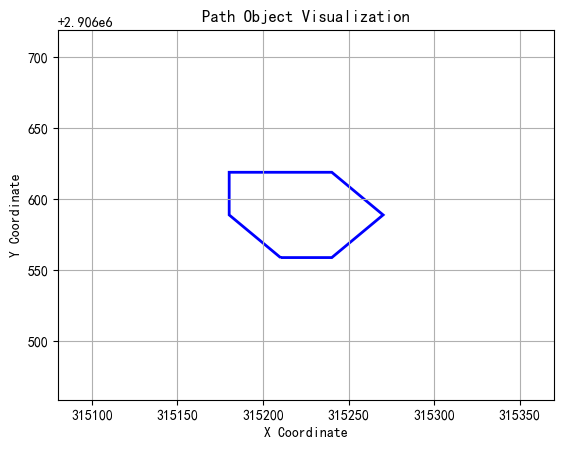

In [118]:

patch = mpatches.PathPatch(polygon_path, facecolor='none', edgecolor='blue', lw=2)

fig, ax = plt.subplots()
ax.add_patch(patch)

ax.set_xlim(min(x for x, y in sorted_neighbors) - 100, max(x for x, y in sorted_neighbors) + 100)
ax.set_ylim(min(y for x, y in sorted_neighbors) - 100, max(y for x, y in sorted_neighbors) + 100)

ax.set_title('Path Object Visualization')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')

ax.grid(True)

plt.show()


In [119]:
optimized_position = optimize_vertex_position(tri_index, mesh, polygon_path, lb, ub)

print("Optimized node positions:", optimized_position)

Optimized node positions: [ 315252.12847551 2906573.019077  ]
